In [2]:
import sys
sys.path.append('..')

### Investigating `minor_ratio` in Waterbirds module

In [14]:
from smoothAttributionPrior.module.utils.waterbirds import WaterbirdsDataset
dataset = WaterbirdsDataset(minor_ratio=0, root_dir='/media/disk1/Data/')

dataset_train = dataset.get_subset(split="train")
dataset_major_val = dataset.get_test_subset(split="val", mode="majority")
dataset_minor_val = dataset.get_test_subset(split="val", mode="minority")
dataset_major_test = dataset.get_test_subset(split="test", mode="majority")
dataset_minor_test = dataset.get_test_subset(split="test", mode="minority")

for dset in [dataset_train, dataset_major_val, dataset_minor_val, dataset_major_test, dataset_minor_test]:
    arr = dset.metadata_array[:,:2]
    print(sum(arr[:,0] == arr[:,1]) / len(arr), len(arr))

print('Works well')

set_major_minor_group_ratio :  0
tensor(1.) 4555
tensor(1.) 600
tensor(0.) 599
tensor(1.) 2897
tensor(0.) 2897
Works well


# Applying minor_ratio in SpuriousDataModule

In [1]:
from smoothAttributionPrior.module.utils.data_module import SpuriousDataModule

root = '/media/disk1/Data/'
dm = SpuriousDataModule(data_dir=root, dataset='SpuriousCatDog', batch_size_train=8, batch_size_test=8, minor_ratio=0.5)
dm.prepare_data()
dm.setup()
tr_loader = dm.train_dataloader()


/home/jj/anaconda3/envs/env44/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Place205 dataset: exist
oxford-iiit-pet dataset: exist
SpuriousCatDog dataset: exist


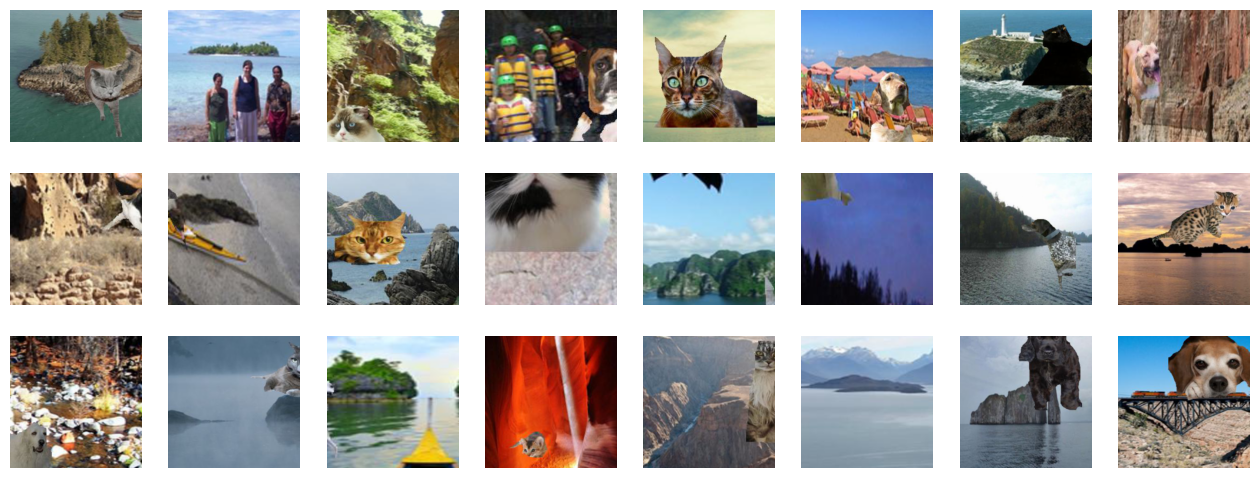

In [4]:
import matplotlib.pyplot as plt
import torch 
mean = torch.tensor((0.485, 0.456, 0.406)).reshape(1,1,3)
std = torch.tensor((0.229, 0.224, 0.225)).reshape(1,1,3)
def ten2im(dat):
    return dat.permute(1,2,0) * std + mean
    
fig, axes = plt.subplots(3,8,figsize=(16,6))
for i, data in enumerate(tr_loader):
    for j in range(8):
        axes[i,j].imshow(ten2im(data[0][j]))
        axes[i,j].axis('off')
    if i == 2:
        break
